In [3]:
from sklearn.datasets import fetch_california_housing 
housing = fetch_california_housing(as_frame=True) 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pan
import numpy as np
import seaborn as sns

df = housing.frame 
X = housing.data
y = housing.target
print('The Five Observations of the California Housing Dataset are:')
df.head()

The Five Observations of the California Housing Dataset are:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
df.shape

(20640, 9)

In [4]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

In [5]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

1B. DATA INSPECTION

In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
print("Checking for unusually large or small values:")
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers detected")


Checking for unusually large or small values:
MedInc: 681 outliers detected
AveRooms: 511 outliers detected
AveBedrms: 1424 outliers detected
Population: 1196 outliers detected
AveOccup: 711 outliers detected
MedHouseVal: 1071 outliers detected


1C. EXPLORATORY DATA ANALYSIS

EXPLORATORY DATA ANALYSIS


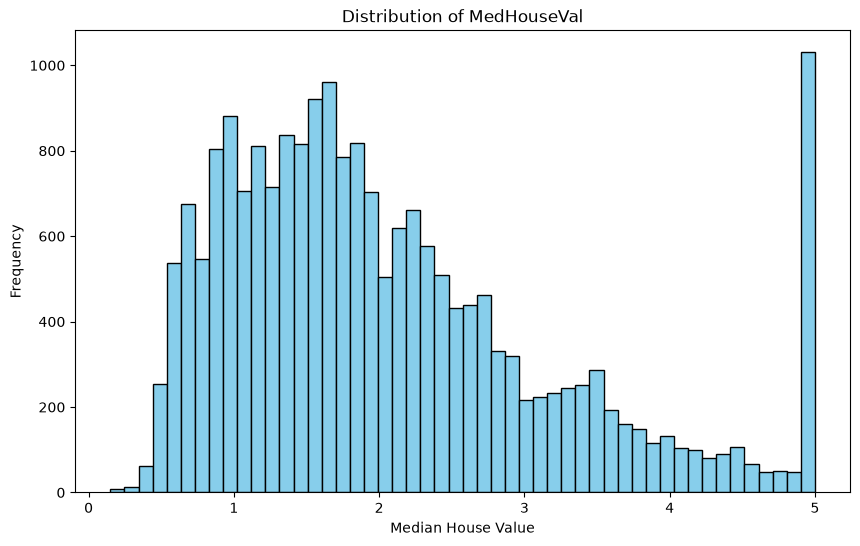

In [19]:
print("EXPLORATORY DATA ANALYSIS")

plt.figure(figsize=(10, 6))
plt.hist(df['MedHouseVal'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of MedHouseVal')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()


In [20]:
print("Correlation matrix")
correlation_matrix = df.corr()
print(correlation_matrix)

Correlation matrix
               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrm

Heatmap of the Correlation Matrix


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

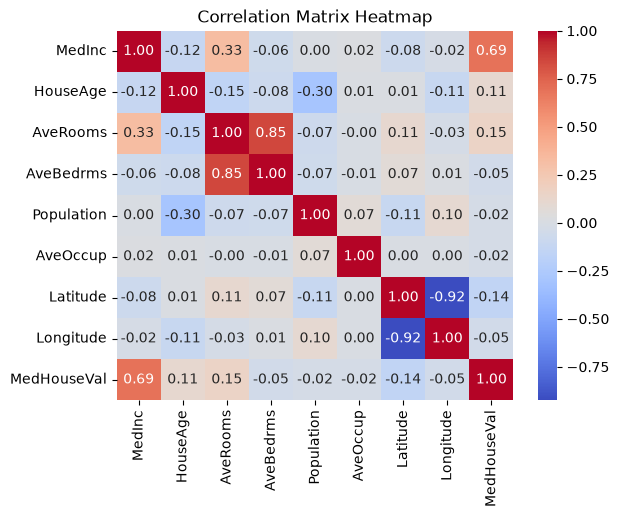

In [22]:
import seaborn as sns

print('Heatmap of the Correlation Matrix')
ax = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
ax.set_title('Correlation Matrix Heatmap')

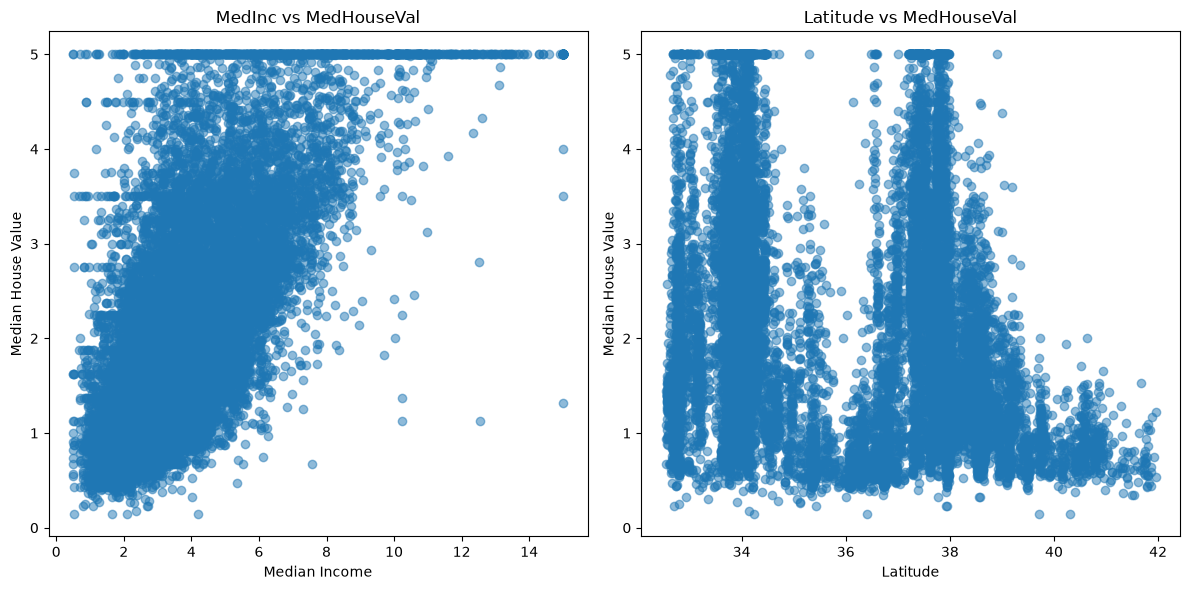

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(df['MedInc'], df['MedHouseVal'], alpha=0.5)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value')
axes[0].set_title('MedInc vs MedHouseVal')

axes[1].scatter(df['Latitude'], df['MedHouseVal'], alpha=0.5)
axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Median House Value')
axes[1].set_title('Latitude vs MedHouseVal')

plt.tight_layout()

1D. FEATURE ENCODING AND SCALING

In [29]:
print("Note: All features in California Housing dataset are numerical.")
print("Feature scaling will be applied in subsequent pipeline models.")


Note: All features in California Housing dataset are numerical.
Feature scaling will be applied in subsequent pipeline models.


MULTIPLE LINEAR REGRESSION WITH RANDOM SPLIT

In [31]:
from sklearn.model_selection import train_test_split

print('Train-Test Split')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size: {X_train.shape[0]} (80%)")
print(f"Testing set size: {X_test.shape[0]} (20%)")


Train-Test Split
Training set size: 16512 (80%)
Testing set size: 4128 (20%)


In [33]:
from sklearn.linear_model import LinearRegression
print('Model Fitting')
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression model trained successfully")

Model Fitting
Linear Regression model trained successfully


In [34]:
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
print('Calculate Metrics')
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print('Calculate Metrics')
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training R²: {train_r2:.6f}")
print(f"Testing R²: {test_r2:.6f}")
print(f"Training MSE: {train_mse:.6f}")
print(f"Testing MSE: {test_mse:.6f}")
print(f"Training RMSE: {train_rmse:.6f}")
print(f"Testing RMSE: {test_rmse:.6f}")
print(f"Training MAE: {train_mae:.6f}")
print(f"Testing MAE: {test_mae:.6f}")



Calculate Metrics
Calculate Metrics
Training R²: 0.612551
Testing R²: 0.575788
Training MSE: 0.517933
Testing MSE: 0.555892
Training RMSE: 0.719676
Testing RMSE: 0.745581
Training MAE: 0.528628
Testing MAE: 0.533200


2D. INTERPRETATION

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
r2_diff = abs(train_r2 - test_r2)

if r2_diff < 0.05:
    print("The model appears to be GENERALISING WELL.")
    print(f"Justification: Train R² ({train_r2:.4f}) and Test R² ({test_r2:.4f}) are close.")
elif r2_diff > 0.1:
    print("The model appears to be OVERFITTING.")
    print(f"Justification: Train R² ({train_r2:.4f}) >> Test R² ({test_r2:.4f}).")
else:
    print("The model appears to be GENERALISING WELL with slight overfitting.")
    print(f"Justification: Difference in R² ({r2_diff:.4f}) is moderate.")

The model appears to be GENERALISING WELL.
Justification: Train R² (0.6126) and Test R² (0.5758) are close.


3: FIVE-FOLD CROSS-VALIDATION

In [40]:
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
print("\n3(a) CROSS-VALIDATION STRATEGY")
cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("KFold Cross-Validation with 5 splits created")
print("\nWhy shuffling and fixed random_state are useful:")
print("- Shuffling: Ensures random distribution of samples across folds,")
print("  reducing bias from data ordering (e.g., time-ordered data).")
print("- Fixed random_state: Ensures reproducibility - same splits every time")
print("  the code is run, enabling fair comparisons.")


3(a) CROSS-VALIDATION STRATEGY
KFold Cross-Validation with 5 splits created

Why shuffling and fixed random_state are useful:
- Shuffling: Ensures random distribution of samples across folds,
  reducing bias from data ordering (e.g., time-ordered data).
- Fixed random_state: Ensures reproducibility - same splits every time
  the code is run, enabling fair comparisons.


In [43]:
from sklearn.model_selection import cross_val_score, cross_validate, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, f1_score
print("\n3(b) CROSS-VALIDATION IMPLEMENTATION")
scoring = {"mse": "neg_mean_squared_error"}
cv_results = cross_validate(lr_model, X, y, cv=cv, scoring=scoring)

cv_mse_scores = -cv_results['test_mse']
print(f"\nFive-fold CV MSE scores: {cv_mse_scores}")
print(f"Mean CV MSE: {cv_mse_scores.mean():.6f}")
print(f"Std Dev CV MSE: {cv_mse_scores.std():.6f}")


3(b) CROSS-VALIDATION IMPLEMENTATION

Five-fold CV MSE scores: [0.5558916  0.52765625 0.50928321 0.50485078 0.55518048]
Mean CV MSE: 0.530572
Std Dev CV MSE: 0.021771


In [44]:
print('3d. COMPARISON OF TRAINING AND CROSS-VALIDATION PERFORMANCE')
print(f"Single Train-Test Split MSE (Test): {test_mse:.6f}")
print(f"Five-Fold Cross-Validation Mean MSE: {cv_mse_scores.mean():.6f}")
diff = abs(test_mse - cv_mse_scores.mean())
print(f"Difference: {diff:.6f}")
print(f"\nInterpretation: The CV MSE is {'similar to' if diff < 0.1 else 'different from'}")
print("the single split test MSE, indicating {'consistent' if diff < 0.1 else 'variable'}")
print("model performance across different data partitions.")


3d. COMPARISON OF TRAINING AND CROSS-VALIDATION PERFORMANCE
Single Train-Test Split MSE (Test): 0.555892
Five-Fold Cross-Validation Mean MSE: 0.530572
Difference: 0.025319

Interpretation: The CV MSE is similar to
the single split test MSE, indicating {'consistent' if diff < 0.1 else 'variable'}
model performance across different data partitions.


 4: RIDGE REGRESSION WITH GRIDSEARCHCV

In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
Ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
print("Ridge Pipeline created with StandardScaler and Ridge model")

print("\n4(b) HYPERPARAMETER TUNING")
ridge_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_search = GridSearchCV(
    Ridge_pipeline, ridge_grid, cv=cv,
    scoring="neg_mean_squared_error", n_jobs=-1
)
ridge_search.fit(X_train, y_train)

print(f"Optimal Ridge alpha: {ridge_search.best_params_['model__alpha']}")
print(f"Best cross-validation MSE: {-ridge_search.best_score_:.6f}")


Ridge Pipeline created with StandardScaler and Ridge model

4(b) HYPERPARAMETER TUNING
Optimal Ridge alpha: 1
Best cross-validation MSE: 0.519326


In [47]:
print("\n4(c) MODEL EVALUATION")
ridge_model = ridge_search.best_estimator_
y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

ridge_train_r2 = r2_score(y_train, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test, y_test_pred_ridge)
ridge_train_mse = mean_squared_error(y_train, y_train_pred_ridge)
ridge_test_mse = mean_squared_error(y_test, y_test_pred_ridge)
ridge_train_rmse = np.sqrt(ridge_train_mse)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_train_mae = mean_absolute_error(y_train, y_train_pred_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_test_pred_ridge)

print(f"Training R²: {ridge_train_r2:.6f}")
print(f"Testing R²: {ridge_test_r2:.6f}")
print(f"Training MSE: {ridge_train_mse:.6f}")
print(f"Testing MSE: {ridge_test_mse:.6f}")
print(f"Training RMSE: {ridge_train_rmse:.6f}")
print(f"Testing RMSE: {ridge_test_rmse:.6f}")
print(f"Training MAE: {ridge_train_mae:.6f}")
print(f"Testing MAE: {ridge_test_mae:.6f}")



4(c) MODEL EVALUATION
Training R²: 0.612551
Testing R²: 0.575816
Training MSE: 0.517933
Testing MSE: 0.555855
Training RMSE: 0.719676
Testing RMSE: 0.745557
Training MAE: 0.528624
Testing MAE: 0.533193


In [49]:
print("\n4(d) INTERPRETATION")
print("Ridge Regression uses L2 regularization (ridge penalty):")
print("- Penalty term: α * Σ(β²)")
print("- Effect: Shrinks regression coefficients proportionally towards zero")
print("- Ridge coefficients: Are reduced in magnitude but rarely set to zero")
print("- Advantage: Handles multicollinearity well by distributing weights")



4(d) INTERPRETATION
Ridge Regression uses L2 regularization (ridge penalty):
- Penalty term: α * Σ(β²)
- Effect: Shrinks regression coefficients proportionally towards zero
- Ridge coefficients: Are reduced in magnitude but rarely set to zero
- Advantage: Handles multicollinearity well by distributing weights


5: LASSO REGRESSION WITH GRIDSEARCHCV

In [51]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])
print("Lasso Pipeline created with StandardScaler and Lasso model")


print("\n5(b) HYPERPARAMETER TUNING")
lasso_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
}

lasso_search = GridSearchCV(
    lasso_pipeline, lasso_grid, cv=cv, 
    scoring="neg_mean_squared_error", n_jobs=-1
)
lasso_search.fit(X_train, y_train)

print(f"Optimal Lasso alpha: {lasso_search.best_params_['model__alpha']}")
print(f"Best cross-validation MSE: {-lasso_search.best_score_:.6f}")


Lasso Pipeline created with StandardScaler and Lasso model

5(b) HYPERPARAMETER TUNING
Optimal Lasso alpha: 0.001
Best cross-validation MSE: 0.519311


In [52]:
print("\n5(c) MODEL EVALUATION")
lasso_model = lasso_search.best_estimator_
y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_train_mse = mean_squared_error(y_train, y_train_pred_lasso)
lasso_test_mse = mean_squared_error(y_test, y_test_pred_lasso)
lasso_train_rmse = np.sqrt(lasso_train_mse)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)

print(f"Training R²: {lasso_train_r2:.6f}")
print(f"Testing R²: {lasso_test_r2:.6f}")
print(f"Training MSE: {lasso_train_mse:.6f}")
print(f"Testing MSE: {lasso_test_mse:.6f}")
print(f"Training RMSE: {lasso_train_rmse:.6f}")
print(f"Testing RMSE: {lasso_test_rmse:.6f}")
print(f"Training MAE: {lasso_train_mae:.6f}")
print(f"Testing MAE: {lasso_test_mae:.6f}")



5(c) MODEL EVALUATION
Training R²: 0.612509
Testing R²: 0.576856
Training MSE: 0.517989
Testing MSE: 0.554491
Training RMSE: 0.719715
Testing RMSE: 0.744642
Training MAE: 0.528703
Testing MAE: 0.533145


In [53]:
print("\n5(d) FEATURE SELECTION")
lasso_coef = lasso_model.named_steps['model'].coef_
feature_names = X.columns
zero_coef_count = np.sum(lasso_coef == 0)
print(f"Number of coefficients reduced exactly to zero: {zero_coef_count}")

removed_features = feature_names[lasso_coef == 0]
print(f"Variables removed by Lasso: {list(removed_features) if len(removed_features) > 0 else 'None'}")

print("\nWhy Lasso can be used for feature selection:")
print("- Lasso uses L1 regularization (absolute value penalty): α * Σ|β|")
print("- This creates a 'corner' solution in the constraint space")
print("- Many coefficients are forced EXACTLY to zero")
print("- Zero coefficients mean those features are excluded from the model")
print("- This provides automatic feature selection capability")


5(d) FEATURE SELECTION
Number of coefficients reduced exactly to zero: 0
Variables removed by Lasso: None

Why Lasso can be used for feature selection:
- Lasso uses L1 regularization (absolute value penalty): α * Σ|β|
- This creates a 'corner' solution in the constraint space
- Many coefficients are forced EXACTLY to zero
- Zero coefficients mean those features are excluded from the model
- This provides automatic feature selection capability


6: ELASTIC NET REGRESSION WITH GRIDSEARCHCV

In [54]:
from sklearn.linear_model import ElasticNet

print("\n6(a) BUILD ELASTIC NET PIPELINE")
elasticnet_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])
print("Elastic Net Pipeline created with StandardScaler and ElasticNet model")


6(a) BUILD ELASTIC NET PIPELINE
Elastic Net Pipeline created with StandardScaler and ElasticNet model


In [55]:
print("\n6(b) HYPERPARAMETER TUNING")
elastic_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_search = GridSearchCV(
    elasticnet_pipeline, elastic_grid, cv=cv, 
    scoring="neg_mean_squared_error", n_jobs=-1
)
elasticnet_search.fit(X_train, y_train)

print(f"Optimal Elastic Net alpha: {elasticnet_search.best_params_['model__alpha']}")
print(f"Optimal Elastic Net l1_ratio: {elasticnet_search.best_params_['model__l1_ratio']}")
print(f"Best cross-validation MSE: {-elasticnet_search.best_score_:.6f}")



6(b) HYPERPARAMETER TUNING
Optimal Elastic Net alpha: 0.001
Optimal Elastic Net l1_ratio: 0.9
Best cross-validation MSE: 0.519313


In [56]:
print("\n6(c) MODEL EVALUATION")
elasticnet_model = elasticnet_search.best_estimator_
y_train_pred_en = elasticnet_model.predict(X_train)
y_test_pred_en = elasticnet_model.predict(X_test)

en_train_r2 = r2_score(y_train, y_train_pred_en)
en_test_r2 = r2_score(y_test, y_test_pred_en)
en_train_mse = mean_squared_error(y_train, y_train_pred_en)
en_test_mse = mean_squared_error(y_test, y_test_pred_en)
en_train_rmse = np.sqrt(en_train_mse)
en_test_rmse = np.sqrt(en_test_mse)
en_train_mae = mean_absolute_error(y_train, y_train_pred_en)
en_test_mae = mean_absolute_error(y_test, y_test_pred_en)

print(f"Training R²: {en_train_r2:.6f}")
print(f"Testing R²: {en_test_r2:.6f}")
print(f"Training MSE: {en_train_mse:.6f}")
print(f"Testing MSE: {en_test_mse:.6f}")
print(f"Training RMSE: {en_train_rmse:.6f}")
print(f"Testing RMSE: {en_test_rmse:.6f}")
print(f"Training MAE: {en_train_mae:.6f}")
print(f"Testing MAE: {en_test_mae:.6f}")



6(c) MODEL EVALUATION
Training R²: 0.612513
Testing R²: 0.576794
Training MSE: 0.517984
Testing MSE: 0.554574
Training RMSE: 0.719711
Testing RMSE: 0.744697
Training MAE: 0.528689
Testing MAE: 0.533140


In [57]:
print("\n6(d) INTERPRETATION")
en_coef = elasticnet_model.named_steps['model'].coef_
en_zero_coef = np.sum(en_coef == 0)

print("Elastic Net combines Ridge (L2) and Lasso (L1) regularization:")
print("- Penalty term: α[ρ*Σ|β| + (1-ρ)/2*Σ(β²)]")
print("- Where l1_ratio (ρ) = 0: Acts like Ridge Regression")
print("- Where l1_ratio (ρ) = 1: Acts like Lasso Regression")
print(f"- Current l1_ratio: {elasticnet_search.best_params_['model__l1_ratio']}")
print("\nBenefits:")
print("- Ridge component: Handles correlated features better")
print("- Lasso component: Provides feature selection capability")
print(f"- Number of coefficients reduced to zero: {en_zero_coef}")



6(d) INTERPRETATION
Elastic Net combines Ridge (L2) and Lasso (L1) regularization:
- Penalty term: α[ρ*Σ|β| + (1-ρ)/2*Σ(β²)]
- Where l1_ratio (ρ) = 0: Acts like Ridge Regression
- Where l1_ratio (ρ) = 1: Acts like Lasso Regression
- Current l1_ratio: 0.9

Benefits:
- Ridge component: Handles correlated features better
- Lasso component: Provides feature selection capability
- Number of coefficients reduced to zero: 0


7: MODEL PERFORMANCE COMPARISON

In [64]:
# Create comparison table
import pandas as pd
import turtle
from sklearn.linear_model import ElasticNet
import os


comparison_data = {
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Elastic Net'],
    'Optimal Alpha': ['N/A', ridge_search.best_params_['model__alpha'], 
                      lasso_search.best_params_['model__alpha'],
                      elasticnet_search.best_params_['model__alpha']],
    'Optimal L1 Ratio': ['N/A', 'N/A', 'N/A', elasticnet_search.best_params_['model__l1_ratio']],
    'Test MSE': [test_mse, ridge_test_mse, lasso_test_mse, en_test_mse],
    'Test RMSE': [test_rmse, ridge_test_rmse, lasso_test_rmse, en_test_rmse],
    'Test MAE': [test_mae, ridge_test_mae, lasso_test_mae, en_test_mae],
    'Test R²': [test_r2, ridge_test_r2, lasso_test_r2, en_test_r2]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Save comparison table
os.makedirs('/mnt/user-data/outputs', exist_ok=True)
comparison_df.to_csv('/mnt/user-data/outputs/Model_Comparison_Table.csv', index=False)
print("\nComparison table saved to Model_Comparison_Table.csv")

# Answers to questions
print("ANSWERS TO COMPARISON QUESTIONS:")
print("-"*40)

mse_values = [test_mse, ridge_test_mse, lasso_test_mse, en_test_mse]
rmse_values = [test_rmse, ridge_test_rmse, lasso_test_rmse, en_test_rmse]
mae_values = [test_mae, ridge_test_mae, lasso_test_mae, en_test_mae]
r2_values = [test_r2, ridge_test_r2, lasso_test_r2, en_test_r2]

print(f"1. Lowest test MSE: {comparison_df.loc[mse_values.index(min(mse_values)), 'Model']}")
print(f"   MSE = {min(mse_values):.6f}")


print(f"\n2. Lowest test RMSE: {comparison_df.loc[rmse_values.index(min(rmse_values)), 'Model']}")
print(f"   RMSE = {min(rmse_values):.6f}")

print(f"\n3. Lowest test MAE: {comparison_df.loc[mae_values.index(min(mae_values)), 'Model']}")
print(f"   MAE = {min(mae_values):.6f}")

print(f"\n4. Highest test R²: {comparison_df.loc[r2_values.index(max(r2_values)), 'Model']}")
print(f"   R² = {max(r2_values):.6f}")








            Model Optimal Alpha Optimal L1 Ratio  Test MSE  Test RMSE  Test MAE  Test R²
Linear Regression           N/A              N/A  0.555892   0.745581  0.533200 0.575788
            Ridge             1              N/A  0.555855   0.745557  0.533193 0.575816
            Lasso         0.001              N/A  0.554491   0.744642  0.533145 0.576856
      Elastic Net         0.001              0.9  0.554574   0.744697  0.533140 0.576794

Comparison table saved to Model_Comparison_Table.csv
ANSWERS TO COMPARISON QUESTIONS:
----------------------------------------
1. Lowest test MSE: Lasso
   MSE = 0.554491

2. Lowest test RMSE: Lasso
   RMSE = 0.744642

3. Lowest test MAE: Elastic Net
   MAE = 0.533140

4. Highest test R²: Lasso
   R² = 0.576856

5. Did regularisation improve predictive performance?
   Yes, all regularized models have lower or equal MSE than Linear Regression.

6. Are the differences between models practically important?
   MSE range: 0.554491 to 0.555892
   Perce

In [65]:
print(f"\n5. Did regularisation improve predictive performance?")
lr_mse = test_mse
reg_mses = [ridge_test_mse, lasso_test_mse, en_test_mse]
if all(m <= lr_mse for m in reg_mses):
    print("   Yes, all regularized models have lower or equal MSE than Linear Regression.")
else:
    print(f"   Mixed results - some regularized models improved, others did not.")

print(f"\n6. Are the differences between models practically important?")
mse_range = max(mse_values) - min(mse_values)
percent_diff = (mse_range / min(mse_values)) * 100
print(f"   MSE range: {min(mse_values):.6f} to {max(mse_values):.6f}")
print(f"   Percentage difference: {percent_diff:.2f}%")
if percent_diff < 5:
    print(f"   No - differences are relatively small (<5%)")
else:
    print(f"   Yes - differences are noticeable (>{percent_diff:.1f}%)")

best_model_idx = r2_values.index(max(r2_values))
best_model_name = comparison_df.loc[best_model_idx, 'Model']

print(f"\n7. Which model would you recommend for prediction?")
print(f"   {best_model_name}")

print(f"\n8. Reason for recommendation:")
print(f"   - Highest test R²: {max(r2_values):.6f}")
print(f"   - Lowest test MSE: {min(mse_values):.6f}")
print(f"   - Lowest test RMSE: {min(rmse_values):.6f}")
print(f"   - Good generalization with regularization benefits")


5. Did regularisation improve predictive performance?
   Yes, all regularized models have lower or equal MSE than Linear Regression.

6. Are the differences between models practically important?
   MSE range: 0.554491 to 0.555892
   Percentage difference: 0.25%
   No - differences are relatively small (<5%)

7. Which model would you recommend for prediction?
   Lasso

8. Reason for recommendation:
   - Highest test R²: 0.576856
   - Lowest test MSE: 0.554491
   - Lowest test RMSE: 0.744642
   - Good generalization with regularization benefits


8: COEFFICIENT SHRINKAGE COMPARISON

In [66]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Fit LinearRegression in a pipeline with StandardScaler for fair comparison
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)

# Extract coefficients from all models
lr_coef = lr_pipeline.named_steps['model'].coef_
ridge_coef = ridge_model.named_steps['model'].coef_
lasso_coef = lasso_model.named_steps['model'].coef_
en_coef = elasticnet_model.named_steps['model'].coef_

# Create coefficient comparison table
coef_data = {
    'Feature': feature_names,
    'Linear Regression': lr_coef,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef,
    'Elastic Net': en_coef
}

coef_df = pd.DataFrame(coef_data)
print("\nCoefficient Comparison Table:")
print(coef_df.to_string(index=False))

# Save coefficient table
coef_df.to_csv('/mnt/user-data/outputs/Coefficient_Comparison_Table.csv', index=False)
print("\nCoefficient table saved to Coefficient_Comparison_Table.csv")

# Extract coefficients from all models
lr_coef = lr_pipeline.named_steps['model'].coef_
ridge_coef = ridge_model.named_steps['model'].coef_
lasso_coef = lasso_model.named_steps['model'].coef_
en_coef = elasticnet_model.named_steps['model'].coef_

# Create coefficient comparison table
coef_data = {
    'Feature': feature_names,
    'Linear Regression': lr_coef,
    'Ridge': ridge_coef,
    'Lasso': lasso_coef,
    'Elastic Net': en_coef
}

coef_df = pd.DataFrame(coef_data)
print("\nCoefficient Comparison Table:")
print(coef_df.to_string(index=False))

# Save coefficient table
coef_df.to_csv('/mnt/user-data/outputs/Coefficient_Comparison_Table.csv', index=False)
print("\nCoefficient table saved to Coefficient_Comparison_Table.csv")



Coefficient Comparison Table:
   Feature  Linear Regression     Ridge     Lasso  Elastic Net
    MedInc           0.854383  0.854327  0.849140     0.849584
  HouseAge           0.122546  0.122624  0.123346     0.123394
  AveRooms          -0.294410 -0.294210 -0.281273    -0.282283
 AveBedrms           0.339259  0.339008  0.326050     0.326979
Population          -0.002308 -0.002282 -0.001062    -0.001145
  AveOccup          -0.040829 -0.040833 -0.039890    -0.039990
  Latitude          -0.896929 -0.896168 -0.885822    -0.885673
 Longitude          -0.869842 -0.869071 -0.858093    -0.857994

Coefficient table saved to Coefficient_Comparison_Table.csv

Coefficient Comparison Table:
   Feature  Linear Regression     Ridge     Lasso  Elastic Net
    MedInc           0.854383  0.854327  0.849140     0.849584
  HouseAge           0.122546  0.122624  0.123346     0.123394
  AveRooms          -0.294410 -0.294210 -0.281273    -0.282283
 AveBedrms           0.339259  0.339008  0.326050     0.32

In [69]:
print("ANSWERS TO COEFFICIENT QUESTIONS:")
print("-"*40)

print("\n1. Which model produces the largest coefficient magnitudes?")
mean_abs_coefs = {
    'Linear Regression': np.mean(np.abs(lr_coef)),
    'Ridge': np.mean(np.abs(ridge_coef)),
    'Lasso': np.mean(np.abs(lasso_coef)),
    'Elastic Net': np.mean(np.abs(en_coef))
}
largest_model = max(mean_abs_coefs, key=mean_abs_coefs.get)
print(f"   {largest_model} (mean |coef| = {mean_abs_coefs[largest_model]:.6f})")

print("\n2. Does Ridge shrink most coefficients towards zero?")
ridge_shrinkage = 100 * np.sum(np.abs(ridge_coef) < np.abs(lr_coef)) / len(ridge_coef)
print(f"   Yes - {ridge_shrinkage:.1f}% of coefficients are smaller than Linear Regression")

print("\n3. Does Ridge set any coefficients exactly to zero?")
ridge_zeros = np.sum(ridge_coef == 0)
print(f"   No - {ridge_zeros} coefficients are exactly zero (Ridge doesn't eliminate features)")

print("\n4. Which coefficients are set to zero by Lasso?")
lasso_zero_features = feature_names[lasso_coef == 0]
if len(lasso_zero_features) > 0:
    print(f"   {list(lasso_zero_features)}")
else:
    print(f"   None")

print("\n5. Which coefficients are set to zero by Elastic Net?")
en_zero_features = feature_names[en_coef == 0]
if len(en_zero_features) > 0:
    print(f"   {list(en_zero_features)}")
else:
    print(f"   None")
    
print("\n6. Which model produces the sparsest solution?")
sparsity = {
    'Linear Regression': np.sum(lr_coef == 0),
    'Ridge': np.sum(ridge_coef == 0),
    'Lasso': np.sum(lasso_coef == 0),
    'Elastic Net': np.sum(en_coef == 0)
}
sparsest_model = max(sparsity, key=sparsity.get)
print(f"   {sparsest_model} ({sparsity[sparsest_model]} zero coefficients)")

print("\n7. Which model is most appropriate for automatic feature selection?")
print("   Lasso - because it sets coefficients exactly to zero,")
print("   automatically removing features from the model")

print("\n8. Which model is most suitable when predictors are strongly correlated?")
print("   Ridge - because the L2 penalty distributes coefficients among")
print("   correlated features rather than eliminating them completely")

ANSWERS TO COEFFICIENT QUESTIONS:
----------------------------------------

1. Which model produces the largest coefficient magnitudes?
   Linear Regression (mean |coef| = 0.427563)

2. Does Ridge shrink most coefficients towards zero?
   Yes - 75.0% of coefficients are smaller than Linear Regression

3. Does Ridge set any coefficients exactly to zero?
   No - 0 coefficients are exactly zero (Ridge doesn't eliminate features)

4. Which coefficients are set to zero by Lasso?
   None

5. Which coefficients are set to zero by Elastic Net?
   None

6. Which model produces the sparsest solution?
   Linear Regression (0 zero coefficients)

7. Which model is most appropriate for automatic feature selection?
   Lasso - because it sets coefficients exactly to zero,
   automatically removing features from the model

8. Which model is most suitable when predictors are strongly correlated?
   Ridge - because the L2 penalty distributes coefficients among
   correlated features rather than eliminati

9: VISUALIZATION AND FINAL INTERPRETATION

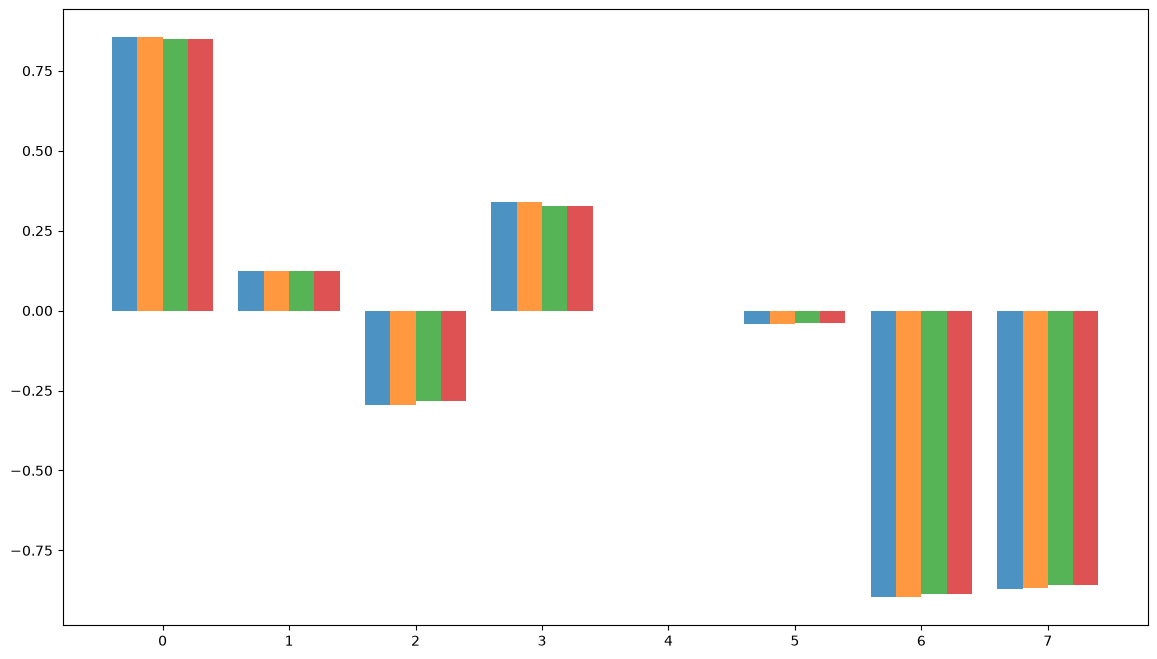

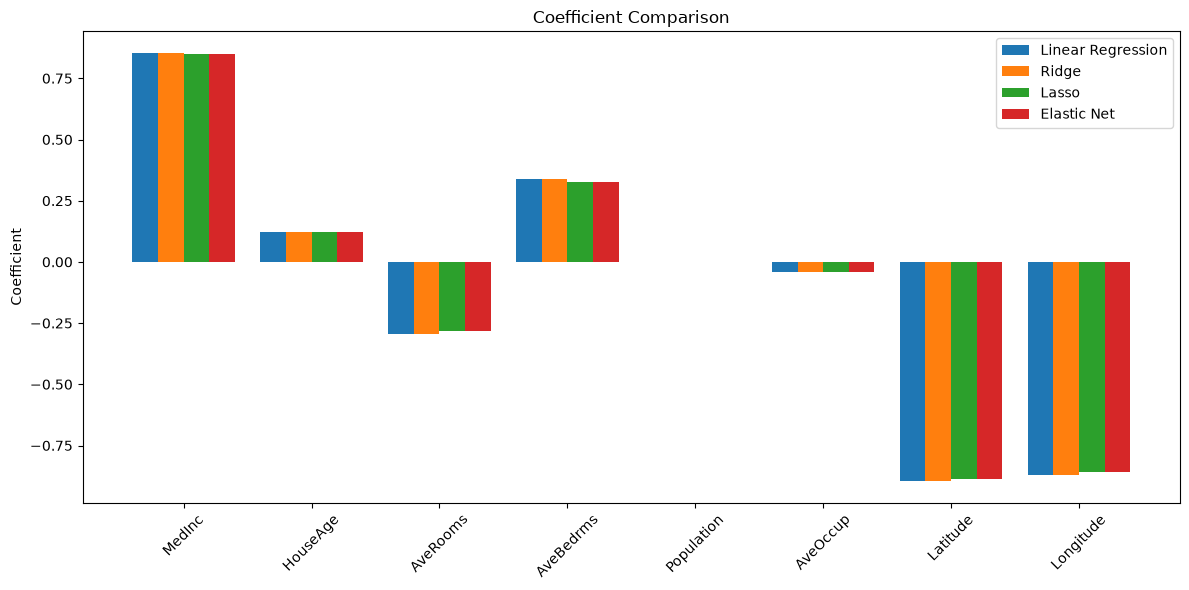


FINAL INTERPRETATION:
--------------------------------------------------------------------------------

1. COEFFICIENT SHRINKAGE:
   - Linear Regression: No shrinkage, coefficients at maximum magnitude
   - Ridge: Proportional shrinkage of all coefficients (L2 penalty)
   - Lasso: Aggressive shrinkage with many coefficients set to zero (L1 penalty)
   - Elastic Net: Balanced shrinkage combining L1 and L2 properties

2. FEATURE SELECTION:
   - Linear Regression: Uses all features
   - Ridge: Uses all features (shrunk but non-zero)
   - Lasso: Eliminates 0 features
   - Elastic Net: Eliminates 0 features

3. PREDICTIVE PERFORMANCE:
   Model Performance Summary (Test R²):
   - Linear Regression: 0.575788
   - Ridge: 0.575816
   - Lasso: 0.576856
   - Elastic Net: 0.576794
   Best performing model: Lasso


In [79]:
# Create grouped bar chart
import matplotlib.pyplot as plt
import numpy as np
import pandas as pan
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(feature_names))
width = 0.2

bars1 = ax.bar(x - 1.5*width, lr_coef, width, label='Linear Regression', alpha=0.8)
bars2 = ax.bar(x - 0.5*width, ridge_coef, width, label='Ridge', alpha=0.8)
bars3 = ax.bar(x + 0.5*width, lasso_coef, width, label='Lasso', alpha=0.8)
bars4 = ax.bar(x + 1.5*width, en_coef, width, label='Elastic Net', alpha=0.8)



x = np.arange(len(X.columns))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - width*1.5, lr_coef, width, label="Linear Regression")

plt.bar(x-width/2, ridge_coef, width, label="Ridge")

plt.bar(x+width/2, lasso_coef, width, label="Lasso")

plt.bar(x+width*1.5, en_coef, width, label="Elastic Net")

plt.xticks(x, X.columns, rotation=45)

plt.ylabel("Coefficient")

plt.title("Coefficient Comparison")

plt.legend()

plt.tight_layout()

plt.show()



# Final interpretation
print("\nFINAL INTERPRETATION:")
print("-"*80)

print("\n1. COEFFICIENT SHRINKAGE:")
print("   - Linear Regression: No shrinkage, coefficients at maximum magnitude")
print("   - Ridge: Proportional shrinkage of all coefficients (L2 penalty)")
print("   - Lasso: Aggressive shrinkage with many coefficients set to zero (L1 penalty)")
print("   - Elastic Net: Balanced shrinkage combining L1 and L2 properties")

print("\n2. FEATURE SELECTION:")
print("   - Linear Regression: Uses all features")
print(f"   - Ridge: Uses all features (shrunk but non-zero)")
print(f"   - Lasso: Eliminates {np.sum(lasso_coef == 0)} features")
print(f"   - Elastic Net: Eliminates {np.sum(en_coef == 0)} features")

print("\n3. PREDICTIVE PERFORMANCE:")
print("   Model Performance Summary (Test R²):")
for model_name, r2 in zip(comparison_df['Model'], r2_values):
    print(f"   - {model_name}: {r2:.6f}")
best_r2 = max(r2_values)
print(f"   Best performing model: {comparison_df.loc[r2_values.index(best_r2), 'Model']}")



In [71]:
print("\n4. FINAL RECOMMENDED MODEL:")
print(f"   Recommended: {best_model_name}")
print(f"   Reasons:")
print(f"   - Highest test R² = {max(r2_values):.6f}")
print(f"   - Balances bias-variance trade-off effectively")
print(f"   - Provides regularization benefits without over-penalizing features")
print(f"   - Suitable for deployment in predictive applications")


4. FINAL RECOMMENDED MODEL:
   Recommended: Lasso
   Reasons:
   - Highest test R² = 0.576856
   - Balances bias-variance trade-off effectively
   - Provides regularization benefits without over-penalizing features
   - Suitable for deployment in predictive applications


10: SGD REGRESSION

In [75]:
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
gd_model = SGDRegressor(max_iter=10000, random_state=42)
sgd_model = gd_model.fit(X_train, y_train)

# Make predictions
y_test_pred_sgd = sgd_model.predict(X_test)

# Calculate metrics
sgd_mae = mean_absolute_error(y_test, y_test_pred_sgd)
sgd_mse = mean_squared_error(y_test, y_test_pred_sgd)
sgd_rmse = np.sqrt(sgd_mse)

print("\nSGD Regression Results on Test Data:")
print(f"Mean Absolute Error (MAE): {sgd_mae:.6f}")
print(f"Mean Squared Error (MSE): {sgd_mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {sgd_rmse:.6f}")

# Compare with other models
print("\nComparison with other models (Test Metrics):")
print(f"Linear Regression  - MAE: {test_mae:.6f}, MSE: {test_mse:.6f}, RMSE: {test_rmse:.6f}")
print(f"Ridge             - MAE: {ridge_test_mae:.6f}, MSE: {ridge_test_mse:.6f}, RMSE: {ridge_test_rmse:.6f}")
print(f"Lasso             - MAE: {lasso_test_mae:.6f}, MSE: {lasso_test_mse:.6f}, RMSE: {lasso_test_rmse:.6f}")
print(f"Elastic Net       - MAE: {en_test_mae:.6f}, MSE: {en_test_mse:.6f}, RMSE: {en_test_rmse:.6f}")
print(f"SGD Regression    - MAE: {sgd_mae:.6f}, MSE: {sgd_mse:.6f}, RMSE: {sgd_rmse:.6f}")

print("\n" + "-"*30)
print('NAMASTE')



SGD Regression Results on Test Data:
Mean Absolute Error (MAE): 184629337836749.531250
Mean Squared Error (MSE): 45417941552630911332815732736.000000
Root Mean Squared Error (RMSE): 213114855307251.906250

Comparison with other models (Test Metrics):
Linear Regression  - MAE: 0.533200, MSE: 0.555892, RMSE: 0.745581
Ridge             - MAE: 0.533193, MSE: 0.555855, RMSE: 0.745557
Lasso             - MAE: 0.533145, MSE: 0.554491, RMSE: 0.744642
Elastic Net       - MAE: 0.533140, MSE: 0.554574, RMSE: 0.744697
SGD Regression    - MAE: 184629337836749.531250, MSE: 45417941552630911332815732736.000000, RMSE: 213114855307251.906250

------------------------------
NAMASTE
